# Skincare Recommendation System

Predict what type of skin care we can use with the help of **Skin Type**, **Alergens**,**Product Type**.

So priority sequence is Skintype and product type and on the basis of allergens I will remove the products which whill contain the allergens from recommendation.

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
skincare = pd.read_excel("FINAL_SKINCARE_DATASET_MAY_2026.xlsx")

In [3]:
df= skincare.copy()

In [4]:
skincare.head(3)

,id,Product Name,Brand,Product Type,image_name,Key Ingredients,Ingredient Functions,Allergens,Suitable Skin Types,Application Time,Price (USD),Product Link,Description
0,1,C E Ferulic,SkinCeuticals,Serum,1.jpeg,Water|Ethoxydiglycol|L Ascorbic Acid|Propylene...,"Antimicrobial / Antibacterial, Antioxidant, Mo...",Phenoxyethanol,"Dry, Sensitive",AM,$182.00,https://www.google.com/search?q=SkinCeuticals+...,A daytime antioxidant serum delivers advanced ...
1,2,Vinoperfect Radiance Serum,Caudalie,Serum,2.jpeg,Water|Butylene Glycol|Glycerin|Squalane|Tocoph...,"Antioxidant, Emollient, Moisturizer / Humectan...",Fragrance,Dry,AM,$82.00,https://www.google.com/search?q=Caudalie+Vinop...,"A highly concentrated, oil-free serum that imp..."
2,3,Pure Hyaluronic Serum,Pestle & Mortar,Serum,3.jpeg,Aqua|Glycerin|Sodium Hyaluronate|Butylene Glyc...,"Emollient, Moisturizer / Humectant, Skin Ident...",Phenoxyethanol,"Combination, Dry, Sensitive",AM/PM,$60.00,https://www.google.com/search?q=Pestle+&+Morta...,"This smooth concentrate targets fine lines, du..."


# EDA

In [5]:
skincare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    1000 non-null   int64 
 1   Product Name          1000 non-null   object
 2   Brand                 1000 non-null   object
 3   Product Type          1000 non-null   object
 4   image_name            1000 non-null   object
 5   Key Ingredients       1000 non-null   object
 6   Ingredient Functions  1000 non-null   object
 7   Allergens             1000 non-null   object
 8   Suitable Skin Types   1000 non-null   object
 9   Application Time      1000 non-null   object
 10  Price (USD)           1000 non-null   object
 11  Product Link          1000 non-null   object
 12  Description           1000 non-null   object
dtypes: int64(1), object(12)
memory usage: 101.7+ KB


In [6]:
skincare.isnull().sum()

id                      0
Product Name            0
Brand                   0
Product Type            0
image_name              0
Key Ingredients         0
Ingredient Functions    0
Allergens               0
Suitable Skin Types     0
Application Time        0
Price (USD)             0
Product Link            0
Description             0
dtype: int64

In [7]:
skincare.isna().sum()

id                      0
Product Name            0
Brand                   0
Product Type            0
image_name              0
Key Ingredients         0
Ingredient Functions    0
Allergens               0
Suitable Skin Types     0
Application Time        0
Price (USD)             0
Product Link            0
Description             0
dtype: int64

In [8]:
skincare.duplicated().sum()

0

In [9]:
skincare.rename(columns={"Product Name" :"Name","Product Type":"Product_Type","Key Ingredients":"Key_Ingredients","Ingredient Functions":"Ingredient_Functions","Suitable Skin Types":"Skin_Types","Application Time":"Time","Price (USD)":"Price","Product Link":"Link"},inplace=True)

In [10]:
skincare.head(2)

,id,Name,Brand,Product_Type,image_name,Key_Ingredients,Ingredient_Functions,Allergens,Skin_Types,Time,Price,Link,Description
0,1,C E Ferulic,SkinCeuticals,Serum,1.jpeg,Water|Ethoxydiglycol|L Ascorbic Acid|Propylene...,"Antimicrobial / Antibacterial, Antioxidant, Mo...",Phenoxyethanol,"Dry, Sensitive",AM,$182.00,https://www.google.com/search?q=SkinCeuticals+...,A daytime antioxidant serum delivers advanced ...
1,2,Vinoperfect Radiance Serum,Caudalie,Serum,2.jpeg,Water|Butylene Glycol|Glycerin|Squalane|Tocoph...,"Antioxidant, Emollient, Moisturizer / Humectan...",Fragrance,Dry,AM,$82.00,https://www.google.com/search?q=Caudalie+Vinop...,"A highly concentrated, oil-free serum that imp..."


# Notes: To remove options based on allergens we need to get the list of unique allergens from the whole dataset.

In [11]:
allergens =  skincare["Allergens"].tolist()

In [12]:
allergens

['Phenoxyethanol',
 'Fragrance',
 'Phenoxyethanol',
 'None identified',
 'Phenoxyethanol',
 'Fragrance, Nut-derived, Phenoxyethanol',
 'Arnica Montana Flower Extract, Capsicum Frutescens Fruit Extract',
 'Commiphora Myrrha Resin Extract, Myrtus Communis Extract, Phenoxyethanol, Thymus Vulgaris (Thyme) Flower/â€‹Leaf Oil',
 'Phenoxyethanol',
 'Alcohol (Denatured), Alcohol Denat., Fragrance, Linalool',
 'Phenoxyethanol',
 'Phenoxyethanol',
 'Phenoxyethanol',
 'Phenoxyethanol',
 'Phenoxyethanol, Piper Methysticum Leaf/â€‹Root/â€‹Stem Extract',
 'None identified',
 'None identified',
 'Phenoxyethanol',
 'Phenoxyethanol',
 'Phenoxyethanol',
 'Nut-derived, Phenoxyethanol, Shea',
 'Phenoxyethanol',
 'Agonis Fragrans (Fragonia) Branch/â€‹Leaf Oil, CitralËš, Citronellol, CitronellolËš, Eucalyptus Radiata (Eucalyptus) Leaf Oil, Geraniol, GeraniolËš, Linalool, LinaloolËš, Melaleuca Teretifolia (Honey Myrtle) Leaf Oil, Nut-derived, Pelargonium Graveolens (Rose Geranium) Leaf Oil',
 'Alcohol, Benzy

In [13]:
clean_allergens = []
for row in allergens:
    parts = row.split(',') # split individual parts by comma
    for item in parts:
        clean_item = item.strip() #clean the unnecessary spaces of the string
        clean_allergens.append(clean_item)

print(clean_allergens)

['Phenoxyethanol', 'Fragrance', 'Phenoxyethanol', 'None identified', 'Phenoxyethanol', 'Fragrance', 'Nut-derived', 'Phenoxyethanol', 'Arnica Montana Flower Extract', 'Capsicum Frutescens Fruit Extract', 'Commiphora Myrrha Resin Extract', 'Myrtus Communis Extract', 'Phenoxyethanol', 'Thymus Vulgaris (Thyme) Flower/â€‹Leaf Oil', 'Phenoxyethanol', 'Alcohol (Denatured)', 'Alcohol Denat.', 'Fragrance', 'Linalool', 'Phenoxyethanol', 'Phenoxyethanol', 'Phenoxyethanol', 'Phenoxyethanol', 'Phenoxyethanol', 'Piper Methysticum Leaf/â€‹Root/â€‹Stem Extract', 'None identified', 'None identified', 'Phenoxyethanol', 'Phenoxyethanol', 'Phenoxyethanol', 'Nut-derived', 'Phenoxyethanol', 'Shea', 'Phenoxyethanol', 'Agonis Fragrans (Fragonia) Branch/â€‹Leaf Oil', 'CitralËš', 'Citronellol', 'CitronellolËš', 'Eucalyptus Radiata (Eucalyptus) Leaf Oil', 'Geraniol', 'GeraniolËš', 'Linalool', 'LinaloolËš', 'Melaleuca Teretifolia (Honey Myrtle) Leaf Oil', 'Nut-derived', 'Pelargonium Graveolens (Rose Geranium) Lea

In [14]:
len(clean_allergens)

2827

In [15]:
len(allergens)

1000

In [16]:
total_allergens = list(set(clean_allergens))
print(len(total_allergens))

262


In [17]:
skincare["Allergens"].value_counts().head(10)

Allergens
Phenoxyethanol                    172
None identified                   162
Fragrance, Phenoxyethanol          23
Nut-derived                        23
Nut-derived, Phenoxyethanol        21
Phenoxyethanol, Shea               16
Fragrance                          15
Shea                               15
Benzyl Alcohol, Phenoxyethanol     12
Benzyl Alcohol                     11
Name: count, dtype: int64

In [18]:
skincare["Skin_Types"].value_counts()

Skin_Types
Combination, Dry, Sensitive          433
Combination, Dry, Oily, Sensitive    161
Dry, Sensitive                       140
Dry                                  100
Combination, Dry                      82
Combination, Sensitive                35
Combination                           15
Sensitive                             12
Combination, Dry, Oily                10
Combination, Oily, Sensitive           6
All skin types                         6
Name: count, dtype: int64

In [19]:
skincare["Product_Type"].value_counts()

Product_Type
Moisturiser         250
Cleanser            165
Serum               127
Mask                 99
Sunscreen            94
Toner/Essence        93
Skincare Product     72
Exfoliant            63
Eye Cream            24
Face Oil             13
Name: count, dtype: int64

# Change columns into lists Complecates things as tfidf takes strings

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

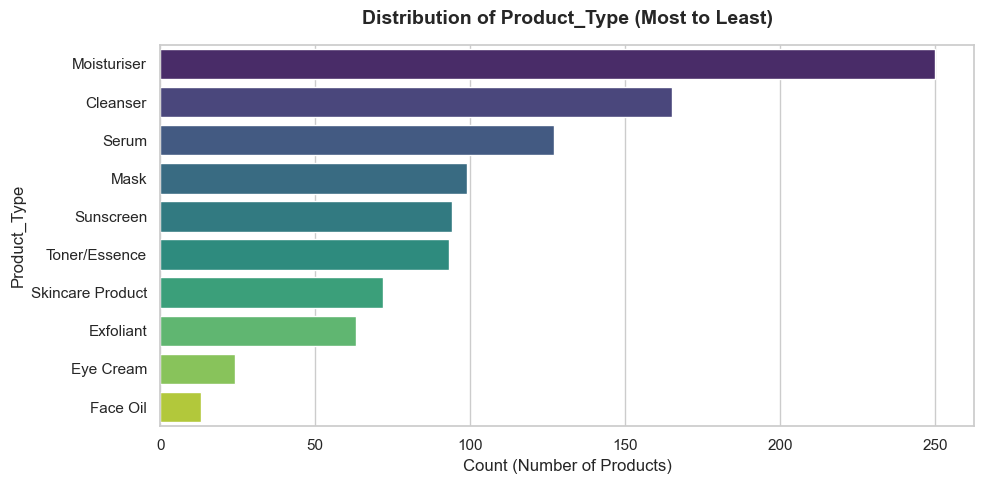

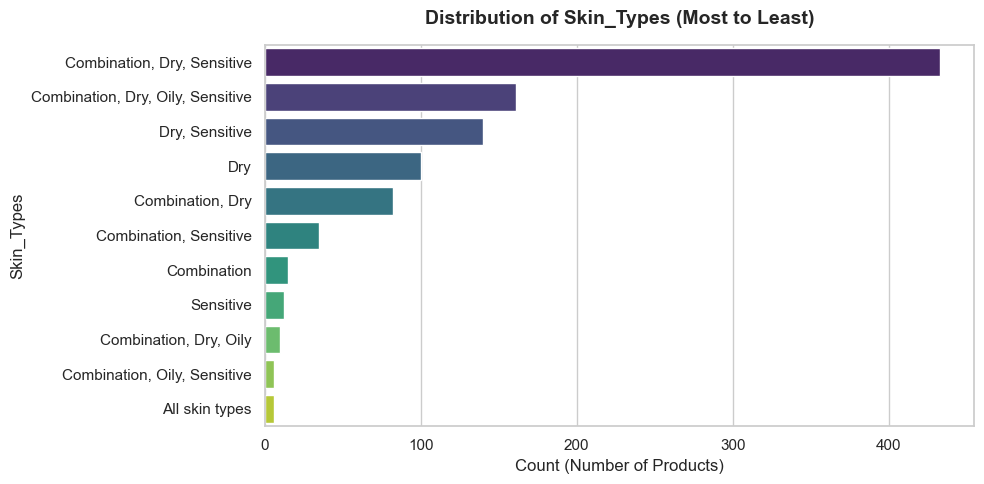

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# The categorical list columns you want to visualize
columns_to_plot = ['Product_Type', 'Skin_Types']

for col in columns_to_plot:
    # 1. Explode the list column to make individual items separate rows
    # 2. Value_counts automatically sorts them in descending order (most to least)
    category_counts = skincare[col].explode().value_counts()

    # Dynamically adjust figure height so long lists (like ingredients/allergens) don't overlap
    fig_height = max(5, len(category_counts) * 0.35)
    plt.figure(figsize=(10, fig_height))

    # Create a horizontal bar chart for excellent label readability
    sns.barplot(
        x=category_counts.values,
        y=category_counts.index,
        palette="viridis",
        hue=category_counts.index,
        legend=False
    )

    # Title and labels formatting
    plt.title(f'Distribution of {col} (Most to Least)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Count (Number of Products)', fontsize=12)
    plt.ylabel(col, fontsize=12)

    # Ensure nothing gets truncated
    plt.tight_layout()
    plt.show()

C:\Users\B BHADURI\AppData\Local\Temp\ipykernel_8720\3933155425.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


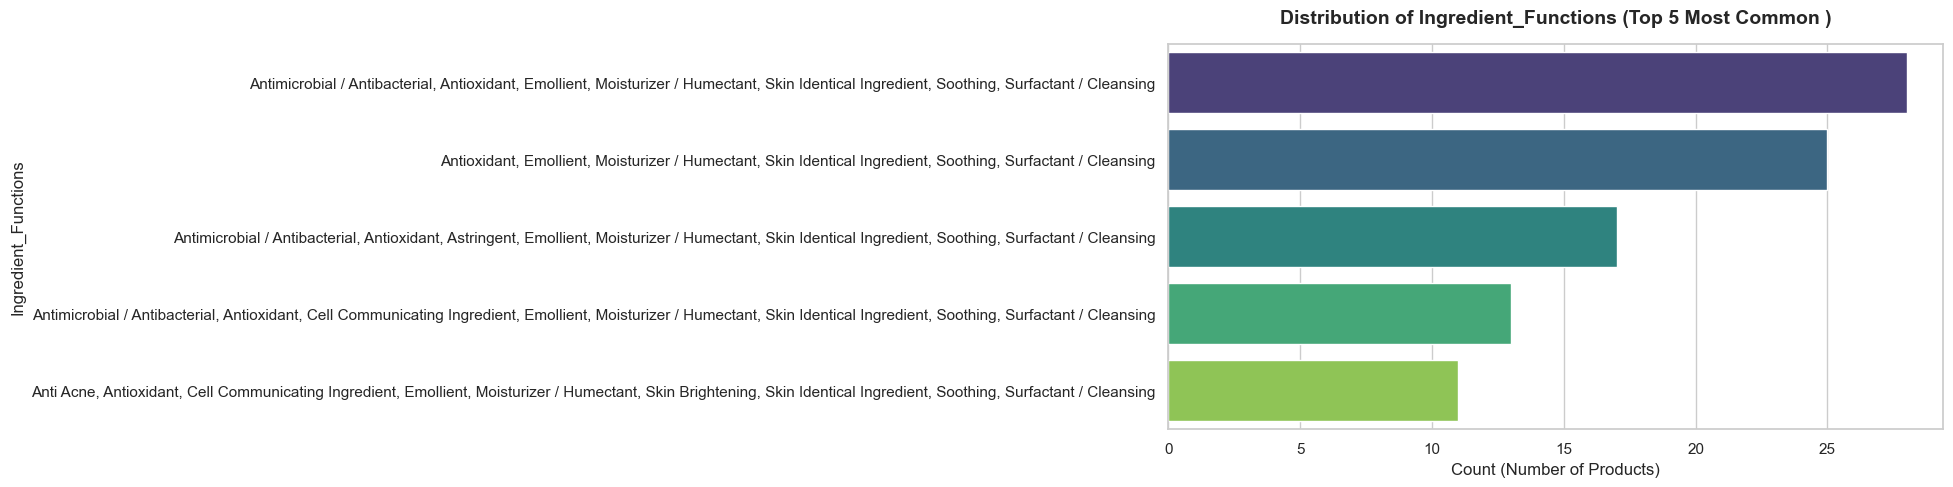

In [22]:
# Set a clean visual style
sns.set_theme(style="whitegrid")

# The categorical list columns you want to visualize
columns_to_plot = ['Ingredient_Functions']

for col in columns_to_plot:
    # 1. Explode the list column to make individual items separate rows
    # 2. Value_counts automatically sorts them in descending order (most to least)
    category_counts = skincare[col].explode().value_counts().head()

    # Dynamically adjust figure height so long lists (like ingredients/allergens) don't overlap
    fig_height = max(5, len(category_counts) * 0.35)
    plt.figure(figsize=(10, fig_height))

    # Create a horizontal bar chart for excellent label readability
    sns.barplot(
        x=category_counts.values,
        y=category_counts.index,
        palette="viridis",
        hue=category_counts.index,
        legend=False
    )

    # Title and labels formatting
    plt.title(f'Distribution of {col} (Top 5 Most Common )', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Count (Number of Products)', fontsize=12)
    plt.ylabel(col, fontsize=12)

    # Ensure nothing gets truncated
    plt.tight_layout()
    plt.show()

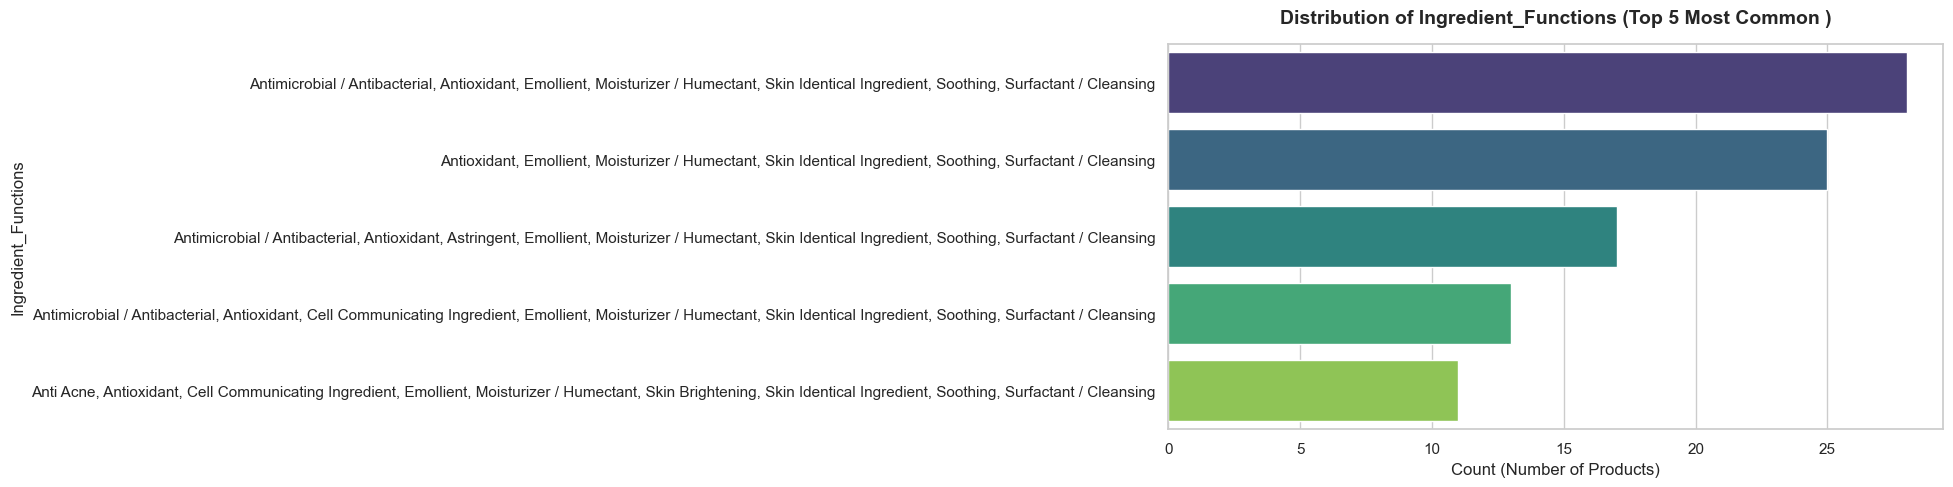

In [23]:
# Set a clean visual style
sns.set_theme(style="whitegrid")

# The categorical list columns you want to visualize
columns_to_plot = ['Ingredient_Functions']

for col in columns_to_plot:
    # 1. Explode the list column to make individual items separate rows
    # 2. Value_counts automatically sorts them in descending order (most to least)
    category_counts = skincare[col].explode().value_counts().head()

    # Dynamically adjust figure height so long lists (like ingredients/allergens) don't overlap
    fig_height = max(5, len(category_counts) * 0.35)
    plt.figure(figsize=(10, fig_height))

    # Create a horizontal bar chart for excellent label readability
    sns.barplot(
        x=category_counts.values,
        y=category_counts.index,
        palette="viridis",
        hue=category_counts.index,
        legend=False
    )

    # Title and labels formatting
    plt.title(f'Distribution of {col} (Top 5 Most Common )', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Count (Number of Products)', fontsize=12)
    plt.ylabel(col, fontsize=12)

    # Ensure nothing gets truncated
    plt.show()

In [24]:
skincare.head()

,id,Name,Brand,Product_Type,image_name,Key_Ingredients,Ingredient_Functions,Allergens,Skin_Types,Time,Price,Link,Description
0,1,C E Ferulic,SkinCeuticals,Serum,1.jpeg,Water|Ethoxydiglycol|L Ascorbic Acid|Propylene...,"Antimicrobial / Antibacterial, Antioxidant, Mo...",Phenoxyethanol,"Dry, Sensitive",AM,$182.00,https://www.google.com/search?q=SkinCeuticals+...,A daytime antioxidant serum delivers advanced ...
1,2,Vinoperfect Radiance Serum,Caudalie,Serum,2.jpeg,Water|Butylene Glycol|Glycerin|Squalane|Tocoph...,"Antioxidant, Emollient, Moisturizer / Humectan...",Fragrance,Dry,AM,$82.00,https://www.google.com/search?q=Caudalie+Vinop...,"A highly concentrated, oil-free serum that imp..."
2,3,Pure Hyaluronic Serum,Pestle & Mortar,Serum,3.jpeg,Aqua|Glycerin|Sodium Hyaluronate|Butylene Glyc...,"Emollient, Moisturizer / Humectant, Skin Ident...",Phenoxyethanol,"Combination, Dry, Sensitive",AM/PM,$60.00,https://www.google.com/search?q=Pestle+&+Morta...,"This smooth concentrate targets fine lines, du..."
3,4,Skin Perfecting 2% Bha Liquid Exfoliant,Paula's Choice,Exfoliant,4.jpeg,Water (Aqua)|Methylpropanediol|Butylene Glycol...,"Anti Acne, Antioxidant, Exfoliant, Moisturizer...",None identified,"Combination, Dry, Oily, Sensitive",PM,$34.00,https://www.google.com/search?q=Paula's+Choice...,"This gentle, leave-on exfoliant rapidly unclog..."
4,5,Bio Essence Intensive Conditioning,IOPE,Toner/Essence,5.jpeg,Saccharomyces Ferment Filtrate|Niacinamide|Gly...,"Anti Acne, Cell Communicating Ingredient, Emol...",Phenoxyethanol,"Combination, Dry, Oily, Sensitive",AM/PM,$52.00,https://www.google.com/search?q=IOPE+Bio+Essen...,The enhanced Bio-redoxâ„¢ in Bio Essence optim...


In [37]:
# ── STEP 3: COMBINED FEATURE ───────────────────────────────────
# Skin Type × 3 (highest priority)
# Product Type × 2 (second priority)
# Description + Key Ingredients (support/context)
skincare['combined'] = (
    skincare['Skin_Types'] + ' ' +
    skincare['Skin_Types'] + ' ' +
    skincare['Skin_Types'] + ' ' +
    skincare['Product_Type'] + ' ' +
    skincare['Product_Type'] 
    
)

In [38]:
# ── STEP 4: TF-IDF + SIMILARITY ────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf      = TfidfVectorizer()
vectors    = tfidf.fit_transform(skincare['combined'])
similarity = cosine_similarity(vectors)

---
## Fix: Allergen Grouping

The dataset has **261 unique allergen strings** — but most are duplicates written differently.
e.g. `Fragrance`, `Parfum`, `Perfume`, `Aroma [Fragrance]` all mean the same thing.

We group them into **35 clean canonical categories** so when a user picks `Fragrance / Parfum`,
it correctly excludes ALL fragrance variants in the dataset.

In [39]:
# Canonical allergen groups: display name → list of keywords to match (lowercase)
ALLERGEN_GROUPS = {
    'Fragrance / Parfum':            ['fragrance', 'parfum', 'perfume', 'aroma'],
    'Alcohol':                       ['alcohol', 'ethanol'],
    'Phenoxyethanol':                ['phenoxyethanol'],
    'Linalool':                      ['linalool', 'linalol'],
    'Limonene':                      ['limonene'],
    'Citronellol':                   ['citronellol'],
    'Geraniol':                      ['geraniol'],
    'Citral':                        ['citral'],
    'Eugenol':                       ['eugenol'],
    'Benzyl Alcohol':                ['benzyl alcohol'],
    'Benzyl Salicylate':             ['benzyl salicylate'],
    'Benzyl Benzoate':               ['benzyl benzoate'],
    'Hexyl Cinnamal':                ['hexyl cinnamal', 'hexyl cinnamaldehyde'],
    'Coumarin':                      ['coumarin'],
    'Farnesol':                      ['farnesol'],
    'Alpha-Isomethyl Ionone':        ['alpha-isomethyl ionone'],
    'Butylphenyl Methylpropional':   ['butylphenyl methylpropional'],
    'Cinnamal':                      ['cinnamal'],
    'Hydroxycitronellal':            ['hydroxycitronellal'],
    'Shea':                          ['shea'],
    'Nut-derived':                   ['nut-derived'],
    'Lanolin':                       ['lanolin'],
    'Ascorbyl Palmitate (Vit C)':    ['ascorbyl palmitate'],
    'Lavender Oil':                  ['lavandula', 'lavender'],
    'Bergamot Oil':                  ['bergamot', 'citrus aurantium bergamia'],
    'Geranium Oil':                  ['pelargonium', 'geranium'],
    'Peppermint Oil':                ['mentha piperita', 'peppermint'],
    'Eucalyptus Oil':                ['eucalyptus'],
    'Rose Oil':                      ['rosa damascena', 'rose oil', 'rose absolute', 'rose otto'],
    'Rosemary Oil':                  ['rosmarinus', 'rosemary'],
    'Ylang Ylang Oil':               ['cananga odorata', 'ylang ylang'],
    'Citrus Oils (Lemon/Orange/Lime/Mandarin)': ['citrus', 'lemon', 'lime peel', 'orange', 'mandarin', 'tangerine', 'grapefruit', 'neroli'],
    'Arnica':                        ['arnica'],
    'Oxybenzone':                    ['oxybenzone', 'benzophenone-3'],
    'Preservatives (MIT/DMDM)':      ['methylisothiazolinone', 'mit (preservative)', 'dmdm', 'diazolidinyl urea', 'methylchloroisothiazolinone'],
}

print(f'Total allergen groups: {len(ALLERGEN_GROUPS)}')
print(list(ALLERGEN_GROUPS.keys()))

Total allergen groups: 35
['Fragrance / Parfum', 'Alcohol', 'Phenoxyethanol', 'Linalool', 'Limonene', 'Citronellol', 'Geraniol', 'Citral', 'Eugenol', 'Benzyl Alcohol', 'Benzyl Salicylate', 'Benzyl Benzoate', 'Hexyl Cinnamal', 'Coumarin', 'Farnesol', 'Alpha-Isomethyl Ionone', 'Butylphenyl Methylpropional', 'Cinnamal', 'Hydroxycitronellal', 'Shea', 'Nut-derived', 'Lanolin', 'Ascorbyl Palmitate (Vit C)', 'Lavender Oil', 'Bergamot Oil', 'Geranium Oil', 'Peppermint Oil', 'Eucalyptus Oil', 'Rose Oil', 'Rosemary Oil', 'Ylang Ylang Oil', 'Citrus Oils (Lemon/Orange/Lime/Mandarin)', 'Arnica', 'Oxybenzone', 'Preservatives (MIT/DMDM)']


In [40]:
def recommend3(skin_type, product_type, avoid_allergens=[], top_n=10,
               df=skincare, tfidf_model=tfidf, vecs=vectors, allergen_grps=ALLERGEN_GROUPS):
    count      = 0
    user_query = (skin_type + ' ') * 4 + (product_type + ' ') * 2
    query_vec  = tfidf_model.transform([user_query])
    scores     = cosine_similarity(query_vec, vecs).flatten()
    ranked     = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)

    results = []
    for idx, score in ranked:
        row = df.loc[idx]

        product_allergens = str(row['Allergens']).lower()
        is_safe = True

        for grp in avoid_allergens:
            keywords = allergen_grps.get(grp, [])
            for kw in keywords:
                if kw in product_allergens:
                    is_safe = False

        if is_safe == False:
            continue

        results.append({
            'name':        row['Name'],
            'brand':       row['Brand'],
            'skin':        row['Skin_Types'],
            'type':        row['Product_Type'],
            'description': row['Description'],
            'ingredients': row['Key_Ingredients'],
            'allergens':   row['Allergens'],
            'time':        row['Time'],
            'price':       row['Price'],
            'score':       round(score, 4),
            'image':       str(row['image_name']),
        })

        count += 1
        if count >= top_n:
            break

    return results



In [41]:
print('Available allergen groups:')
for i, name in enumerate(ALLERGEN_GROUPS.keys(), 1):
    print(f'  {i:2d}. {name}')

print()
print('Skin types: Dry | Oily | Combination | Sensitive | All skin types')
skin = input('Your skin type: ')

print('Product types: Moisturiser | Cleanser | Serum | Mask | Sunscreen | Toner/Essence | Exfoliant | Eye Cream | Face Oil')
ptype = input('Preferred product type: ')

print('Enter allergen group numbers to avoid, comma separated (e.g. 1,3) — or press Enter to skip:')
raw = input('Allergen numbers: ').strip()

allergen_keys = list(ALLERGEN_GROUPS.keys())
if raw:
    chosen = [allergen_keys[int(x.strip()) - 1] for x in raw.split(',') if x.strip().isdigit()]
else:
    chosen = []

print(f'\nAvoiding: {chosen if chosen else "Nothing"}')
print()
recommend3(
    skin_type      = skin ,
    product_type   = ptype ,
    avoid_allergens = chosen)

Available allergen groups:
   1. Fragrance / Parfum
   2. Alcohol
   3. Phenoxyethanol
   4. Linalool
   5. Limonene
   6. Citronellol
   7. Geraniol
   8. Citral
   9. Eugenol
  10. Benzyl Alcohol
  11. Benzyl Salicylate
  12. Benzyl Benzoate
  13. Hexyl Cinnamal
  14. Coumarin
  15. Farnesol
  16. Alpha-Isomethyl Ionone
  17. Butylphenyl Methylpropional
  18. Cinnamal
  19. Hydroxycitronellal
  20. Shea
  21. Nut-derived
  22. Lanolin
  23. Ascorbyl Palmitate (Vit C)
  24. Lavender Oil
  25. Bergamot Oil
  26. Geranium Oil
  27. Peppermint Oil
  28. Eucalyptus Oil
  29. Rose Oil
  30. Rosemary Oil
  31. Ylang Ylang Oil
  32. Citrus Oils (Lemon/Orange/Lime/Mandarin)
  33. Arnica
  34. Oxybenzone
  35. Preservatives (MIT/DMDM)

Skin types: Dry | Oily | Combination | Sensitive | All skin types


Your skin type:  Combination


Product types: Moisturiser | Cleanser | Serum | Mask | Sunscreen | Toner/Essence | Exfoliant | Eye Cream | Face Oil


Preferred product type:  Mask


Enter allergen group numbers to avoid, comma separated (e.g. 1,3) — or press Enter to skip:


Allergen numbers:  1,3,5



Avoiding: ['Fragrance / Parfum', 'Phenoxyethanol', 'Limonene']



[{'name': 'Green Tea Clay Mask',
  'brand': 'Whamisa by Glow Recipe',
  'skin': 'Combination, Dry',
  'type': 'Mask',
  'description': "A fluffy, soft 'never-dry' detoxifying clay mask that deep cleans and refines pores while leaving skin deeply hydrated, balanced, and radiant.",
  'ingredients': 'Camellia Sinensis Leaf Water|Aspalathus Linearis Leaf Extract|Kaolin|Camellia Sinensis Powder|Camellia Sinensis Leaf|Camellia Sinensis Seed Oil|Brassica Oleracea Acephala Leaf Extract|Brassica Oleracea Italica (Broccoli) Extract|Spinacia Oleracea (Spinach) Leaf Extract|Apium Graveolens (Celery) Extract|Stearic Acid|Clay|Cetyl Alcohol|Glycerin|Beeswax|Lactobacillus/Camellia Sinensis Leaf Ferment Filtrate|Spirulina Platensis Extract|Scutellaria Baicalensis Root Extract|Paeonia Suffruticosa Root Extract|Glycyrrhiza Glabra (Licorice) Root Extract|Aniba Rosaeodora (Rosewood) Wood Oil|Citrus Aurantium Bergamia (Bergamot) Fruit Oil|Geranium Maculatum Oil|Rosmarinus Officinalis (Rosemary) Leaf Oil',


In [42]:
import pickle

In [43]:
# Save everything needed by app3.py
pickle.dump(skincare,    open('skincare_df.pkl',       'wb'))
pickle.dump(tfidf,       open('tfidf.pkl',             'wb'))
pickle.dump(vectors,     open('vectors.pkl',           'wb'))
pickle.dump(ALLERGEN_GROUPS, open('allergen_groups.pkl', 'wb'))
pickle.dump(recommend3, open('recommend3.pkl', 'wb'))